## 📦 Geração dos Dados e Simulação da Base

Nesta atividade, iniciamos com a construção de uma base de dados simulada, contendo 100 registros de compras realizadas por diferentes perfis de consumidores. A base inclui variáveis como:

- Nome, idade e sexo do cliente;
- Produto comprado e seu respectivo preço;
- Horário da compra e dia da semana.

Os preços foram gerados com base em uma **distribuição qui-quadrado**, que não segue uma distribuição normal, justamente para representar dados com assimetria e valores extremos — uma condição comum em contextos reais de mercado.

Essa etapa faz parte da **análise exploratória de dados (EDA)**, que é essencial dentro da disciplina de **Reconhecimento de Padrões**, pois permite observar o comportamento dos dados antes de aplicar algoritmos de classificação, clustering ou detecção de anomalias.




In [3]:
%pip install Faker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from faker import Faker
import random
from datetime import datetime

# Configuração inicial
fake = Faker('pt_BR')
random.seed(42)
np.random.seed(42)
Faker.seed(42)

# Produtos disponíveis
produtos = [
    "Smartphone", "Notebook", "Tênis de corrida", "Bolsa feminina", "Câmera digital", "Perfume importado",
    "Relógio esportivo", "Smart TV", "Fone Bluetooth", "Livro de autoajuda", "Console de videogame",
    "Jaqueta jeans", "Tablet", "Brinco de prata", "Cafeteira elétrica"
]

dias_semana = ["Segunda-feira", "Terça-feira", "Quarta-feira", "Quinta-feira", "Sexta-feira", "Sábado", "Domingo"]

def gerar_horario():
    hora = random.randint(8, 22)
    minuto = random.randint(0, 59)
    return f"{hora:02d}:{minuto:02d}"

# Gerar os dados
def gerar_dataset(n=100):
    dados = []
    for i in range(n):
        idade = random.randint(18, 65)
        sexo = random.choice(["M", "F"])
        produto = random.choice(produtos)
        preco = round(np.random.chisquare(df=3)*150, 2) + 50
        horario = gerar_horario()
        dia_semana = random.choice(dias_semana)
        dados.append([i+1, fake.first_name(), idade, sexo, produto, preco, horario, dia_semana])
    return pd.DataFrame(dados, columns=["ID", "Nome", "Idade", "Sexo", "Produto", "Preço (R$)", "Horário da Compra", "Dia da Semana"])

# Criar DataFrame
df = gerar_dataset(100)
df.head()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 23.0 MB/s eta 0:00:00


,ID,Nome,Idade,Sexo,Produto,Preço (R$),Horário da Compra,Dia da Semana
0,1,Henry Gabriel,58,M,Smartphone,586.89,19:17,Terça-feira
1,2,Benicio,32,M,Jaqueta jeans,357.08,09:43,Sábado
2,3,Yan,52,M,Livro de autoajuda,329.48,14:02,Segunda-feira
3,4,Samuel,23,M,Bolsa feminina,329.48,16:38,Segunda-feira
4,5,Pietro,53,M,Jaqueta jeans,1201.63,18:44,Sexta-feira


In [30]:
print(f"O Conjunto de dados possui {df.shape[1]} variáveis e {df.shape[0]} observações. \n")
print(f"{'='*50}\nAs colunas e sua tipagem\n{'='*50}\n")

df.info()
print(f"{'='*50}\nAs últimas 5 observações do dataset\n{'='*50}\n")
display(df.tail())
print(f"{'='*50}\nAnálise Estatística das colunas numéricas\n{'='*50}\n")

df.describe()

O Conjunto de dados possui 10 variáveis e 100 observações. 

As colunas e sua tipagem

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 100 non-null    int64  
 1   Nome               100 non-null    object 
 2   Idade              100 non-null    int64  
 3   Sexo               100 non-null    object 
 4   Produto            100 non-null    object 
 5   Preço (R$)         100 non-null    float64
 6   Horário da Compra  100 non-null    object 
 7   Dia da Semana      100 non-null    object 
 8   Faixa Etária       100 non-null    object 
 9   Hora Numérica      100 non-null    float64
dtypes: float64(2), int64(2), object(6)
memory usage: 7.9+ KB
As últimas 5 observações do dataset



,ID,Nome,Idade,Sexo,Produto,Preço (R$),Horário da Compra,Dia da Semana,Faixa Etária,Hora Numérica
95,96,Pedro Lucas,29,F,Smartphone,1419.50,09:38,Quinta-feira,Adulto,9.633333
96,97,João Guilherme,40,F,Relógio esportivo,577.09,17:32,Segunda-feira,Adulto,17.533333
97,98,Nicole,42,M,Câmera digital,169.64,08:45,Quinta-feira,Sênior,8.750000
98,99,Marina,18,M,Perfume importado,722.01,14:04,Sábado,Jovem,14.066667
99,100,Fernando,39,F,Console de videogame,814.18,21:07,Sábado,Adulto,21.116667


Análise Estatística das colunas numéricas



,ID,Idade,Preço (R$),Hora Numérica
count,100.000000,100.000000,100.000000,100.000000
mean,50.500000,37.440000,482.083700,15.414500
std,29.011492,14.076501,320.180757,4.618509
min,1.000000,18.000000,73.750000,8.166667
25%,25.750000,24.750000,265.242500,11.500000
50%,50.500000,35.000000,421.285000,14.825000
75%,75.250000,50.000000,600.095000,18.995833
max,100.000000,65.000000,1958.680000,22.966667


## 📊 Análise de Frequência por Faixa Etária

Abaixo, visualizamos a distribuição da quantidade de compras de acordo com a **faixa etária** dos clientes, que foi classificada da seguinte forma:

- **Jovem**: até 24 anos
- **Adulto**: de 25 a 40 anos
- **Sênior**: acima de 40 anos

Essa categorização nos permite realizar **classificações supervisionadas** e análises de comportamento com base em grupos.

Esse tipo de abordagem é fundamental em **Reconhecimento de Padrões**, pois permite a identificação de agrupamentos naturais (clusters) que podem ser usados posteriormente em modelos de machine learning ou em estratégias de segmentação de mercado.


In [4]:
def faixa_etaria(idade):
    if idade <= 24:
        return "Jovem"
    elif idade <= 40:
        return "Adulto"
    else:
        return "Sênior"

df["Faixa Etária"] = df["Idade"].apply(faixa_etaria)

# Converter horário em formato numérico
df["Hora Numérica"] = df["Horário da Compra"].apply(lambda x: int(x.split(":")[0]) + int(x.split(":")[1])/60)


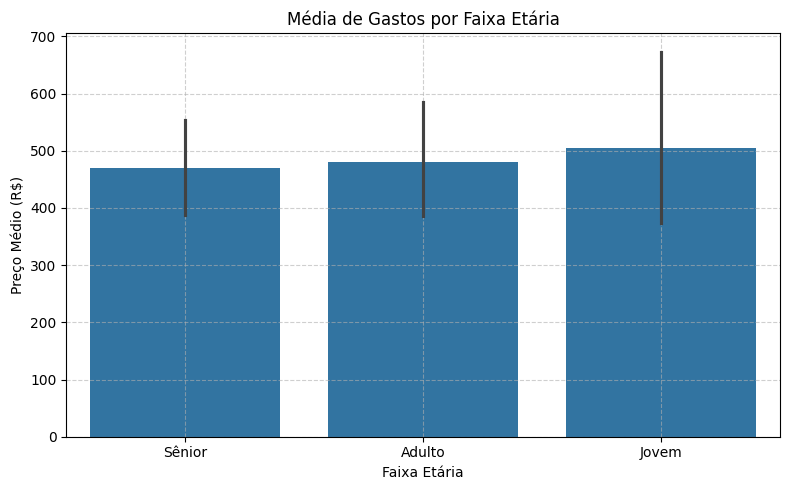

In [5]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Faixa Etária", y="Preço (R$)", estimator=np.mean)
plt.title("Média de Gastos por Faixa Etária")
plt.ylabel("Preço Médio (R$)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 💰 Distribuição dos Preços das Compras

Utilizando um histograma com curva de densidade (KDE), analisamos como os preços se distribuem entre as compras realizadas.

Observamos que os preços seguem uma **distribuição assimétrica (não normal)**, com muitos valores concentrados na faixa de R$ 100 a R$ 600, mas com **alguns valores muito altos**, gerando uma longa cauda.

Esse tipo de análise ajuda a:

- Identificar **outliers (valores extremos)**;
- Compreender a variabilidade dos dados;
- Avaliar a necessidade de transformações futuras (ex: logaritmo).

Na disciplina de Reconhecimento de Padrões, esse tipo de análise é essencial para a preparação dos dados e construção de modelos robustos.


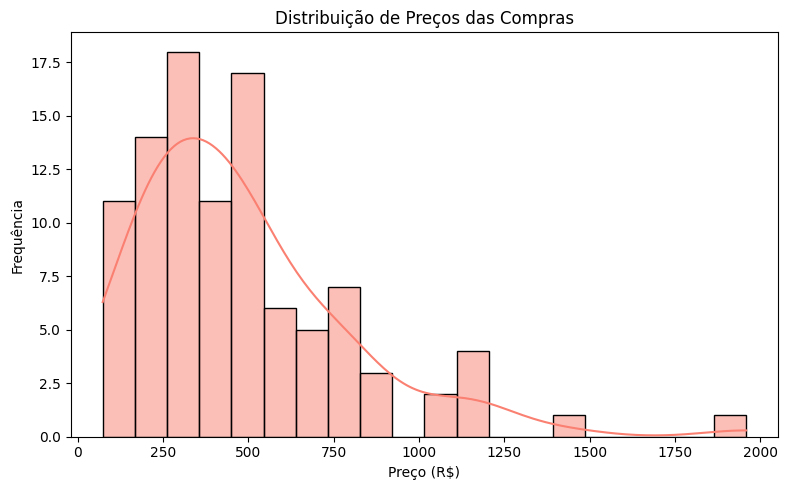

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico: Distribuição de preços (histograma)
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Preço (R$)", bins=20, kde=True, color="salmon")
plt.title("Distribuição de Preços das Compras")
plt.xlabel("Preço (R$)")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

## 📅 Análise Temporal: Compras por Dia da Semana

Aqui visualizamos a quantidade de compras realizadas em cada dia da semana. Essa análise permite identificar **padrões temporais de comportamento**, como:

- Aumento de compras aos finais de semana;
- Picos em dias específicos (como terça ou sexta-feira);
- Estratégias ideais para promoções e campanhas.

Esses padrões são extremamente úteis para a **modelagem preditiva de comportamento**, um dos focos centrais da disciplina de Reconhecimento de Padrões. Com essas informações, empresas podem prever demanda e **ajustar a logística, marketing e atendimento**.


/tmp/ipython-input-177927352.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Dia da Semana", order=dias_semana, palette="viridis")


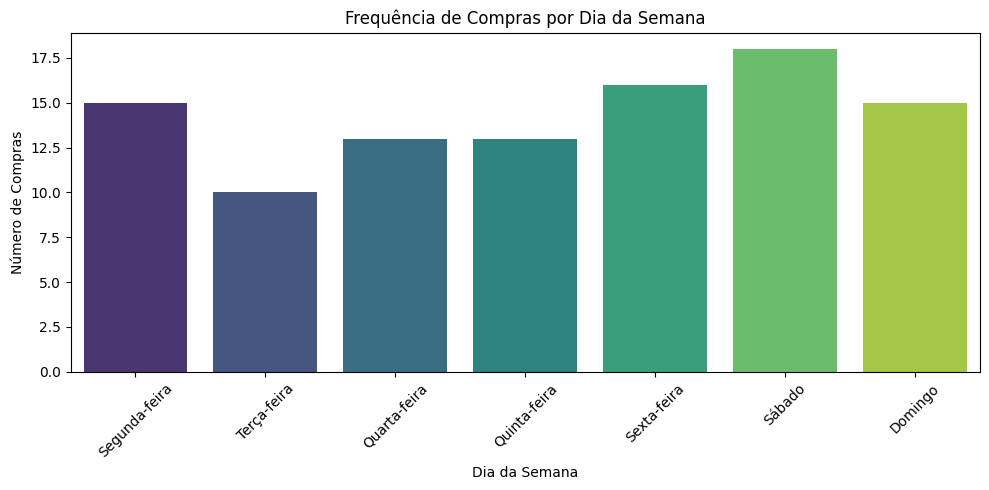

In [9]:
# Gráfico: Compras por Dia da Semana
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Dia da Semana", order=dias_semana, palette="viridis")
plt.title("Frequência de Compras por Dia da Semana")
plt.xlabel("Dia da Semana")
plt.ylabel("Número de Compras")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 👨‍🦰👩‍🦰 Comparação de Preço por Sexo (Boxplot)

O boxplot abaixo compara os valores das compras realizadas por clientes do sexo masculino e feminino. Esse tipo de gráfico ajuda a identificar:

- **Distribuição dos dados** por grupo;
- **Mediana e quartis**;
- **Outliers** — clientes que fizeram compras com valores muito acima do comum.

Na disciplina, o uso de boxplots está relacionado à **análise de padrões de dispersão e comportamento**, além de possibilitar a criação de **modelos discriminativos**, que conseguem diferenciar categorias (como sexo ou faixa etária) com base em variáveis como preço.


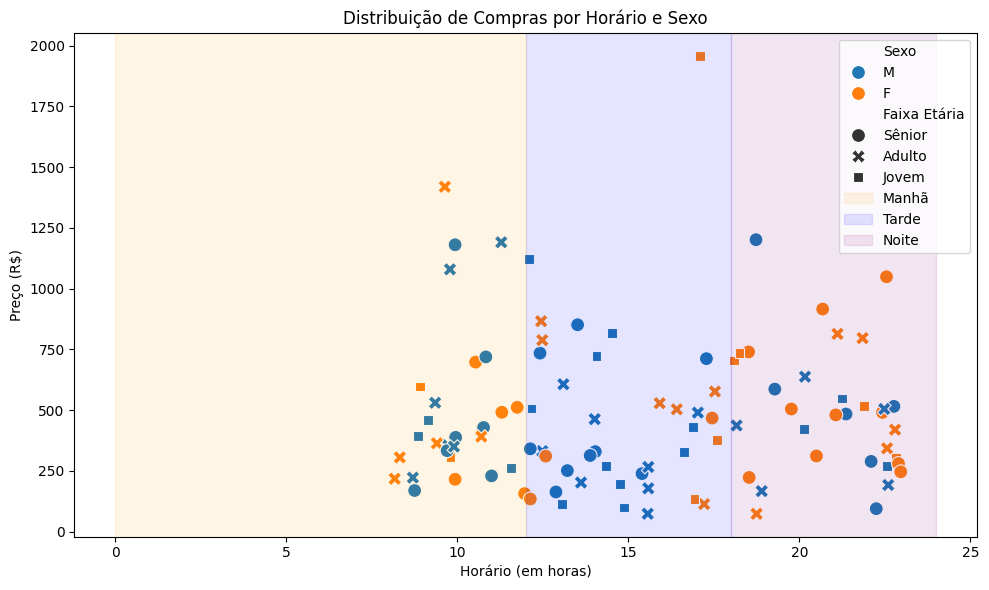

In [10]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Hora Numérica", y="Preço (R$)", hue="Sexo", style="Faixa Etária", s=100)
plt.axvspan(0, 12, color='orange', alpha=0.1, label='Manhã')
plt.axvspan(12, 18, color='blue', alpha=0.1, label='Tarde')
plt.axvspan(18, 24, color='purple', alpha=0.1, label='Noite')
plt.title("Distribuição de Compras por Horário e Sexo")
plt.xlabel("Horário (em horas)")
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipython-input-1324205644.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Sexo", y="Preço (R$)", palette="pastel")


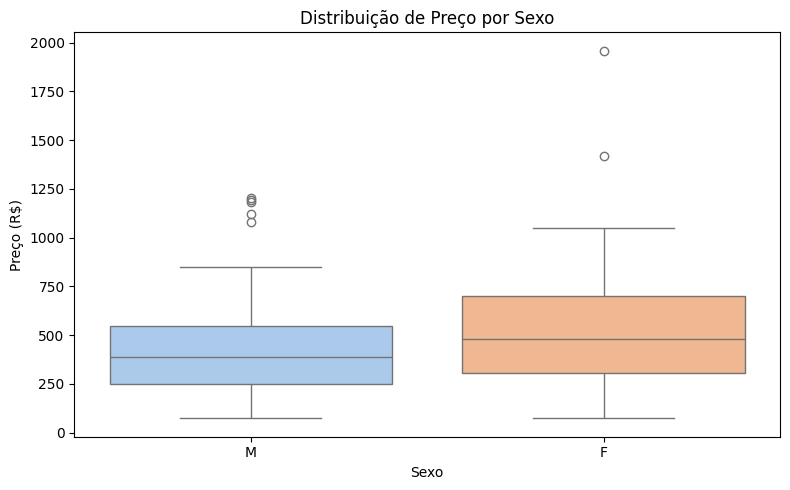

In [11]:

# Gráfico: Boxplot de Preços por Sexo
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Sexo", y="Preço (R$)", palette="pastel")
plt.title("Distribuição de Preço por Sexo")
plt.xlabel("Sexo")
plt.ylabel("Preço (R$)")
plt.tight_layout()
plt.show()
